# **Project Name**    - Local Food Wastage Management System


##### **Project Type**    - Data Analysis
##### **Contribution**    - Individual
##### **Team Member-**    - Pavan Kumar Dirisala



# Problem Statement

Food wastage is a growing concern, with large amounts of edible food discarded daily while many people struggle with hunger and food insecurity. Restaurants, grocery stores, and households often generate surplus food due to overproduction and short shelf life, but there is no structured system to connect this surplus with those in need.

The absence of an efficient redistribution mechanism results in wasted food, lost resources, and increased environmental impact. At the same time, NGOs, community centers, and individuals face challenges in accessing sufficient food supplies.

To address this gap, a **Local Food Wastage Management System** is required. The system should allow food providers to list surplus items, enable receivers to claim them, and maintain structured records through an SQL database. With interactive analysis and a user-friendly Streamlit interface, the solution aims to minimize waste, promote sustainability, and ensure timely redistribution of food to those who need it most.





#  Project Summary

Food wastage has emerged as one of the most pressing global challenges of the 21st century, with millions of tons of edible food being discarded each year while millions of people continue to suffer from hunger and food insecurity. Restaurants, grocery stores, and households frequently generate surplus food that goes unused, either due to overproduction, lack of demand forecasting, or short shelf life. On the other hand, a large number of NGOs, community centers, and individuals are in urgent need of such resources. This paradox inspired the development of the **Local Food Wastage Management System**, a data-driven solution aimed at bridging the gap between food providers and food receivers through a transparent, accessible, and scalable platform.

The project leverages **Python, SQL, and Streamlit** to design a system that enables stakeholders to efficiently manage food donations, monitor food claims, and analyze patterns in food wastage and redistribution. The key objective is not only to minimize waste but also to ensure equitable distribution of food to those who need it most. The system connects **providers** (such as restaurants, grocery stores, and supermarkets) with **receivers** (NGOs, community centers, and individuals), allowing them to list, filter, and claim food donations with ease.

The backbone of the project lies in a **relational SQL database**, which stores structured data about providers, receivers, food listings, and claims. The database schema has been carefully designed with primary keys, foreign keys, and data validation to maintain referential integrity. For example, each food item is linked to a valid provider, and each claim is mapped to both a food item and a receiver. This ensures consistency and accuracy while preventing invalid transactions. To build the database, raw datasets were first preprocessed using Python’s pandas library. Steps included renaming inconsistent column headers, standardizing categorical values, converting date fields into proper datetime formats, and handling missing or duplicate records. Once cleaned, the data was inserted into normalized SQL tables for efficient querying.

A series of **15 SQL queries** were developed to answer critical business questions and extract insights from the data. These queries cover multiple dimensions, such as:

* **Food Providers & Receivers** – analyzing distribution across cities, identifying the most active contributors, and retrieving contact details.
* **Food Listings & Availability** – estimating the total surplus food, identifying top cities by availability, and analyzing food categories.
* **Claims & Distribution** – tracking claims per food item, monitoring provider performance, and evaluating claim success ratios.
* **Analysis & Insights** – computing average claims per receiver, identifying the most in-demand meal types, quantifying contributions by providers, and assessing city-wise demand.

The results of these queries were visualized through bar charts, pie charts, and summary tables within the notebook, making the insights easily interpretable. For example, pie charts were used to represent the distribution of claim statuses (completed, pending, canceled), while bar charts highlighted the top providers or receivers in terms of activity.

To make the system **interactive and accessible**, a **Streamlit application** was developed as the front-end interface. The app provides filters to search for food donations by city, provider type, or food category, and allows receivers to view contact information for direct coordination. Additionally, the app implements full **CRUD operations** (Create, Read, Update, Delete) for food listings, enabling real-time management of donations. For decision-making, all 15 SQL queries and their visual outputs were integrated into the app, allowing stakeholders to explore insights dynamically without needing SQL expertise.

In summary, this project demonstrates how a combination of **data analysis, database management, and interactive visualization** can provide practical solutions to social challenges. The Local Food Wastage Management System not only helps in reducing waste but also ensures food is redistributed to those who need it the most, thereby contributing to both **sustainability and social good**. With scalability and real-time deployment, this system has the potential to be adopted by local communities, NGOs, and government bodies to create a significant impact in combating food wastage.



# **GitHub Link -**

https://github.com/Pavan-Kumar-Dirisala/Local-Food-Wastage-Management-System

## Installing all the required libraries

In [ ]:
!pip install SQLAlchemy pymysql pandas matplotlib seaborn


## Dataset Loading
In this step, we import the required datasets into our Python environment using pandas. 
The project uses four CSV files:
- Providers Dataset (providers_data.csv)
    - Contains details of food providers such as restaurants, grocery stores, and supermarkets.
- Receivers Dataset (receivers_data.csv)
    - Contains details of receivers such as NGOs, community centers, and individuals.
- Food Listings Dataset (food_listings_data.csv)
    - Stores information about surplus food available for distribution, including type, quantity, location, and expiry date.
- Claims Dataset (claims_data.csv)
    - Tracks food claims made by receivers, along with status and timestamps.
    
We will load these datasets into pandas DataFrames for initial exploration and preprocessing.


In [ ]:
import pandas as pd

# Load datasets
providers = pd.read_csv("data/providers_data.csv")
receivers = pd.read_csv("data/receivers_data.csv")
food_listings = pd.read_csv("data/food_listings_data.csv")
claims = pd.read_csv("data/claims_data.csv")


✅ Preprocessing Completed




##  Exploratory Data Analysis (EDA)

After loading the datasets, the next step is to **explore and understand the structure of the data**. We will:

* View the **first few rows** of each dataset using `.head()`
* Inspect **column names, data types, and missing values** using `.info()`
* Generate **basic statistics** for numerical fields using `.describe()`
* Check for **duplicates and null values**

This helps identify potential issues such as inconsistent data types, missing entries, or duplicate records before moving to preprocessing.


###  Dataset Preview & Observations

In [ ]:
# Preview first few rows of each dataset
print("Providers Dataset:")
display(providers.head())

print("\nReceivers Dataset:")
display(receivers.head())

print("\nFood Listings Dataset:")
display(food_listings.head())

print("\nClaims Dataset:")
display(claims.head())


Providers Dataset:


,provider_id,name,type,address,city,contact
0,1,Gonzales-Cochran,Supermarket,"74347 Christopher Extensions\nAndreamouth, OK ...",New Jessica,+1-600-220-0480
1,2,"Nielsen, Johnson and Fuller",Grocery Store,"91228 Hanson Stream\nWelchtown, OR 27136",East Sheena,+1-925-283-8901x6297
2,3,Miller-Black,Supermarket,"561 Martinez Point Suite 507\nGuzmanchester, W...",Lake Jesusview,001-517-295-2206
3,4,"Clark, Prince and Williams",Grocery Store,"467 Bell Trail Suite 409\nPort Jesus, IA 61188",Mendezmouth,556.944.8935x401
4,5,Coleman-Farley,Grocery Store,"078 Matthew Creek Apt. 319\nSaraborough, MA 53978",Valentineside,193.714.6577



Receivers Dataset:


,receiver_id,name,type,city,contact
0,1,Donald Gomez,Shelter,Port Carlburgh,(955)922-5295
1,2,Laurie Ramos,Individual,Lewisburgh,761.042.1570
2,3,Ashley Mckee,Ngo,South Randalltown,691-023-0094x856
3,4,Erika Rose,Ngo,South Shaneville,8296491111
4,5,John Romero,Individual,Bakerport,067.491.0154



Food Listings Dataset:


,food_id,food_name,quantity,expiry_date,provider_id,provider_type,location,food_type,meal_type
0,1,Bread,43,2025-03-17,110,Grocery Store,South Kellyville,Non-Vegetarian,Breakfast
1,2,Soup,22,2025-03-24,791,Grocery Store,West James,Non-Vegetarian,Dinner
2,3,Fruits,46,2025-03-28,478,Catering Service,Lake Regina,Vegan,Breakfast
3,4,Fruits,15,2025-03-16,930,Restaurant,Kellytown,Vegan,Lunch
4,5,Soup,14,2025-03-19,279,Restaurant,Garciaport,Vegan,Dinner



Claims Dataset:


,claim_id,food_id,receiver_id,status,timestamp
0,1,164,908,Pending,2025-03-05 05:26:00
1,2,353,391,Cancelled,2025-03-11 10:24:00
2,3,626,492,Completed,2025-03-21 00:59:00
3,4,61,933,Cancelled,2025-03-04 09:08:00
4,5,345,229,Pending,2025-03-14 15:17:00


#### 1. Providers Dataset

* Contains details of food **providers** such as supermarkets, restaurants, and grocery stores.
* Key columns: `provider_id`, `name`, `type`, `address`, `city`, `contact`.
* Sample entries show that providers are spread across multiple cities with diverse provider types (Supermarket, Grocery Store, etc.).
* Contact information appears in mixed formats (phone numbers with extensions, dots, or brackets), which may require standardization.

#### 2. Receivers Dataset

* Contains details of **receivers** such as NGOs, shelters, community centers, and individuals.
* Key columns: `receiver_id`, `name`, `type`, `city`, `contact`.
* Some categorical values for `type` are inconsistent (e.g., `"Ngo"`, `"Shelter"`, `"Individual"`) — we will need to standardize casing.
* Contact numbers also appear in mixed formats, which may need preprocessing.

#### 3. Food Listings Dataset

* Contains records of **surplus food items** available for donation.
* Key columns: `food_id`, `food_name`, `quantity`, `expiry_date`, `provider_id`, `provider_type`, `location`, `food_type`, `meal_type`.
* Food categories include **Vegetarian, Non-Vegetarian, Vegan**, etc., and meal types include **Breakfast, Lunch, Dinner, Snacks**.
* The `expiry_date` column is already in a proper date format (`YYYY-MM-DD`).
* Some provider types like `"Catering Service"` appear in this dataset but were not seen in the providers dataset sample — needs validation.

#### 4. Claims Dataset

* Contains records of **claims made by receivers** for available food.
* Key columns: `claim_id`, `food_id`, `receiver_id`, `status`, `timestamp`.
* Claim statuses include **Pending, Completed, and Cancelled**.
* The `timestamp` field is in datetime format (`YYYY-MM-DD HH:MM:SS`).
* Receiver IDs and Food IDs must be cross-checked with their respective datasets to maintain referential integrity.



### Dataset Info & Findings

In [ ]:
# Check info and datatypes
print("Providers Info:")
print(providers.info(), "\n")

print("Receivers Info:")
print(receivers.info(), "\n")

print("Food Listings Info:")
print(food_listings.info(), "\n")

print("Claims Info:")
print(claims.info(), "\n")


Providers Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   provider_id  1000 non-null   int64 
 1   name         1000 non-null   object
 2   type         1000 non-null   object
 3   address      1000 non-null   object
 4   city         1000 non-null   object
 5   contact      1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB
None 

Receivers Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   receiver_id  1000 non-null   int64 
 1   name         1000 non-null   object
 2   type         1000 non-null   object
 3   city         1000 non-null   object
 4   contact      1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB
None 

Food Listings Info:
<class 

* **Providers:** 1000 rows, 6 columns. All non-null, correct dtypes. Only `provider_id` is numeric, others are text.
* **Receivers:** 1000 rows, 5 columns. Clean and consistent, no missing values.
* **Food Listings:** 1000 rows, 9 columns. `expiry_date` already datetime, quantities numeric. Categorical fields (`provider_type`, `meal_type`) may need cleaning.
* **Claims:** 1000 rows, 5 columns. `timestamp` parsed as datetime, status values categorical.

Overall: Data is clean, no null values. Minor preprocessing needed for categorical consistency and standardization.




### Summary Statistics Insights

In [ ]:
# Summary statistics
print("Providers Summary:")
display(providers.describe(include="all"))

print("\nReceivers Summary:")
display(receivers.describe(include="all"))

print("\nFood Listings Summary:")
display(food_listings.describe(include="all"))

print("\nClaims Summary:")
display(claims.describe(include="all"))


Providers Summary:


,provider_id,name,type,address,city,contact
count,1000.000000,1000,1000,1000,1000,1000
unique,NaN,973,4,1000,963,1000
top,NaN,Brown and Sons,Supermarket,"74347 Christopher Extensions\nAndreamouth, OK ...",New Carol,+1-600-220-0480
freq,NaN,4,262,1,3,1
mean,500.500000,NaN,NaN,NaN,NaN,NaN
std,288.819436,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,250.750000,NaN,NaN,NaN,NaN,NaN
50%,500.500000,NaN,NaN,NaN,NaN,NaN
75%,750.250000,NaN,NaN,NaN,NaN,NaN



Receivers Summary:


,receiver_id,name,type,city,contact
count,1000.000000,1000,1000,1000,1000
unique,NaN,992,4,966,1000
top,NaN,Heather Brown,Ngo,New Christopher,(955)922-5295
freq,NaN,2,274,3,1
mean,500.500000,NaN,NaN,NaN,NaN
std,288.819436,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,250.750000,NaN,NaN,NaN,NaN
50%,500.500000,NaN,NaN,NaN,NaN
75%,750.250000,NaN,NaN,NaN,NaN



Food Listings Summary:


,food_id,food_name,quantity,expiry_date,provider_id,provider_type,location,food_type,meal_type
count,1000.000000,1000,1000.000000,1000,1000.000,1000,1000,1000,1000
unique,NaN,10,NaN,NaN,NaN,4,624,3,4
top,NaN,Rice,NaN,NaN,NaN,Supermarket,New Carol,Vegetarian,Breakfast
freq,NaN,114,NaN,NaN,NaN,267,6,336,254
mean,500.500000,NaN,25.794000,2025-03-23 00:24:28.800000,497.497,NaN,NaN,NaN,NaN
min,1.000000,NaN,1.000000,2025-03-16 00:00:00,1.000,NaN,NaN,NaN,NaN
25%,250.750000,NaN,13.000000,2025-03-19 00:00:00,241.000,NaN,NaN,NaN,NaN
50%,500.500000,NaN,26.000000,2025-03-23 00:00:00,498.500,NaN,NaN,NaN,NaN
75%,750.250000,NaN,39.000000,2025-03-27 00:00:00,752.000,NaN,NaN,NaN,NaN
max,1000.000000,NaN,50.000000,2025-03-30 00:00:00,1000.000,NaN,NaN,NaN,NaN



Claims Summary:


,claim_id,food_id,receiver_id,status,timestamp
count,1000.000000,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,Completed,NaN
freq,NaN,NaN,NaN,339,NaN
mean,500.500000,502.163000,492.437000,NaN,2025-03-11 11:20:59.400000
min,1.000000,1.000000,1.000000,NaN,2025-03-01 00:09:00
25%,250.750000,233.750000,256.000000,NaN,2025-03-06 17:42:15
50%,500.500000,504.500000,480.500000,NaN,2025-03-11 16:08:00
75%,750.250000,762.000000,742.250000,NaN,2025-03-16 09:29:45
max,1000.000000,999.000000,1000.000000,NaN,2025-03-21 06:12:00


* **Providers:**

  * 973 unique provider names, 4 provider types (e.g., Supermarket is most frequent with 262 entries).
  * Cities are diverse (963 unique), indicating wide coverage.

* **Receivers:**

  * 992 unique names, 4 receiver types (NGOs most common with 274 entries).
  * 966 unique cities, showing broad participation.

* **Food Listings:**

  * 10 distinct food items; *Rice* is most common (114 entries).
  * Quantities range **1–50**, with mean ≈ 26.
  * Provider type = Supermarkets dominate (267).
  * Food types mostly *Vegetarian* (336), meals are spread across 4 types (Breakfast most common).
  * Expiry dates concentrated in **March 2025**.

* **Claims:**

  * 1000 claims; statuses: *Completed* (339), others likely *Pending*/*In Progress*.
  * Claim timestamps span **1–21 March 2025**, showing consistent activity.

Overall: The system is balanced with many unique providers/receivers, diverse food categories, and active claims flow, indicating realistic dataset quality.



### Missing Values & Duplicates Check

In [ ]:
# Check nulls and duplicates
print("Missing Values:")
print("Providers:\n", providers.isnull().sum(), "\n")
print("Receivers:\n", receivers.isnull().sum(), "\n")
print("Food Listings:\n", food_listings.isnull().sum(), "\n")
print("Claims:\n", claims.isnull().sum(), "\n")

print("Duplicates:")
print("Providers:", providers.duplicated().sum())
print("Receivers:", receivers.duplicated().sum())
print("Food Listings:", food_listings.duplicated().sum())
print("Claims:", claims.duplicated().sum())




Missing Values:
Providers:
 provider_id    0
name           0
type           0
address        0
city           0
contact        0
dtype: int64 

Receivers:
 receiver_id    0
name           0
type           0
city           0
contact        0
dtype: int64 

Food Listings:
 food_id          0
food_name        0
quantity         0
expiry_date      0
provider_id      0
provider_type    0
location         0
food_type        0
meal_type        0
dtype: int64 

Claims:
 claim_id       0
food_id        0
receiver_id    0
status         0
timestamp      0
dtype: int64 

Duplicates:
Providers: 0
Receivers: 0
Food Listings: 0
Claims: 0





* **No missing values** across all four datasets (Providers, Receivers, Food Listings, Claims).
* **No duplicate records** detected in any dataset.

The data is **clean and consistent**, ready for analysis and database operations.




### Data Cleaning – Providers

In [ ]:

# ---------- Providers ----------
# Strip spaces from column names
providers.columns = providers.columns.str.strip().str.lower()
# Remove duplicates
providers.drop_duplicates(inplace=True)
# Standardize casing for provider type
providers['type'] = providers['type'].str.title().str.strip()
# Ensure contact is string
providers['contact'] = providers['contact'].astype(str)






* **Column names standardized** → converted to lowercase and stripped of extra spaces for consistency.
* **Removed duplicate records** to maintain data integrity.
* **Provider type normalized** → converted to *title case* (e.g., “supermarket” → “Supermarket”).
* **Contact field converted to string** to avoid numeric formatting issues.

 This ensures the `providers` dataset is clean, uniform, and ready for integration with other tables.

### Data Cleaning – Receivers

In [ ]:

# ---------- Receivers ----------
receivers.columns = receivers.columns.str.strip().str.lower()
receivers.drop_duplicates(inplace=True)
receivers['type'] = receivers['type'].str.title().str.strip()
receivers['contact'] = receivers['contact'].astype(str)






* **Standardized column names** → lowercase and stripped spaces for uniformity.
* **Removed duplicates** → ensures each receiver record is unique.
* **Normalized receiver type** → converted to *title case* (e.g., `ngo` → `Ngo`).
* **Converted contact numbers to string** → prevents issues like loss of leading zeros or unwanted numeric formatting.

Now the `receivers` dataset is clean, standardized, and aligned with the providers’ table.


### Data Cleaning – Food Listings

In [ ]:

# ---------- Food Listings ----------
food_listings.columns = food_listings.columns.str.strip().str.lower()
food_listings.drop_duplicates(inplace=True)
# Convert expiry_date to datetime
food_listings['expiry_date'] = pd.to_datetime(food_listings['expiry_date'], errors='coerce')
# Standardize food type and meal type
food_listings['food_type'] = food_listings['food_type'].str.title().str.strip()
food_listings['meal_type'] = food_listings['meal_type'].str.title().str.strip()





* **Standardized column names** → converted to lowercase, stripped spaces.
* **Removed duplicates** → ensures each food listing is unique.
* **Converted `expiry_date` to datetime** → allows easy filtering for expired/valid food.
* **Normalized categorical fields** →

  * `food_type` → *title case* (e.g., `vegetarian` → `Vegetarian`).
  * `meal_type` → *title case* (e.g., `breakfast` → `Breakfast`).

 Now the `food_listings` dataset is properly structured for temporal analysis (expiry trends), aggregation by meal type, and food type distribution.


### Data Cleaning – Claims

In [ ]:

# ---------- Claims ----------
claims.columns = claims.columns.str.strip().str.lower()
claims.drop_duplicates(inplace=True)
claims['timestamp'] = pd.to_datetime(claims['timestamp'], errors='coerce')
claims['status'] = claims['status'].str.title().str.strip()

print("✅ Preprocessing Completed")






* **Standardized column names** → converted to lowercase, stripped spaces.
* **Removed duplicates** → ensures each claim record is unique.
* **Converted `timestamp` to datetime** → enables chronological analysis (claims trend, peak hours).
* **Normalized `status` values** → title-cased (e.g., `completed` → `Completed`, `pending` → `Pending`).

 This makes claims data reliable for tracking food distribution, monitoring completion rates, and analyzing request timelines.



### Database Connection and Foreign Key Setup

In [ ]:
import sqlite3

conn = sqlite3.connect("database.db")
cursor = conn.cursor()

# Enable foreign key constraints in SQLite
cursor.execute("PRAGMA foreign_keys = ON;")


✅ Tables Created with Primary Keys & Foreign Keys




We begin by creating a connection to the SQLite database named `database.db`.  
A cursor object is initialized to execute SQL commands. Additionally, we enable **foreign key constraints** using `PRAGMA foreign_keys = ON;`. This ensures referential integrity across related tables, meaning that relationships between providers, receivers, food listings, and claims remain consistent and valid.


### Creating Database Schema

In [ ]:

# Create tables with schema
cursor.executescript("""
CREATE TABLE providers (
    provider_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    type TEXT,
    address TEXT,
    city TEXT NOT NULL,
    contact TEXT
);

CREATE TABLE receivers (
    receiver_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    type TEXT,
    city TEXT NOT NULL,
    contact TEXT
);

CREATE TABLE food_listings (
    food_id INTEGER PRIMARY KEY,
    food_name TEXT NOT NULL,
    quantity INTEGER NOT NULL CHECK(quantity > 0),
    expiry_date DATE NOT NULL,
    provider_id INTEGER,
    provider_type TEXT,
    location TEXT,
    food_type TEXT,
    meal_type TEXT,
    FOREIGN KEY (provider_id) REFERENCES providers(provider_id)
);

CREATE TABLE claims (
    claim_id INTEGER PRIMARY KEY,
    food_id INTEGER,
    receiver_id INTEGER,
    status TEXT,
    timestamp DATETIME,
    FOREIGN KEY (food_id) REFERENCES food_listings(food_id),
    FOREIGN KEY (receiver_id) REFERENCES receivers(receiver_id)
);
""")




In this step, we define the **database schema** by creating four interrelated tables:  

1. **Providers** – Stores information about food providers (restaurants, supermarkets, etc.) including name, type, city, and contact details.  
2. **Receivers** – Stores details of receivers (NGOs, individuals, etc.) who request or claim surplus food.  
3. **Food Listings** – Records food items donated by providers, including food name, quantity, expiry date, type, and provider reference. A foreign key links each listing to the corresponding provider.  
4. **Claims** – Tracks requests from receivers for specific food items, along with status and timestamp. Foreign keys link claims to both food listings and receivers.  

Foreign key constraints ensure **referential integrity** between providers, receivers, food listings, and claims.


### Committing and Finalizing Table Creation  

In [ ]:

conn.commit()
print("✅ Tables Created with Primary Keys & Foreign Keys")




After defining the schema, we **commit the changes** to ensure that all tables are created and stored in the database.  
This step also verifies that primary keys and foreign key constraints have been successfully applied.  


### Inserting Data into Tables  

In [62]:
providers.to_sql("providers", conn, if_exists="append", index=False)
receivers.to_sql("receivers", conn, if_exists="append", index=False)
food_listings.to_sql("food_listings", conn, if_exists="append", index=False)
claims.to_sql("claims", conn, if_exists="append", index=False)

print("✅ Data inserted with correct schema")


✅ Data inserted with correct schema




Once the database schema was created, the cleaned datasets (`providers`, `receivers`, `food_listings`, and `claims`)  
were **inserted into their respective tables**.  

- `to_sql()` is used to directly load the Pandas DataFrames into SQLite tables.  
- The parameter `if_exists="append"` ensures that the data is appended instead of overwriting existing tables.  
- The parameter `index=False` prevents unnecessary DataFrame indices from being inserted as extra columns.  

This step ensures that all preprocessed data is properly stored in the database with the correct schema.  


## Food Providers & Receivers

### Q1. How many food providers and receivers are there in each city?

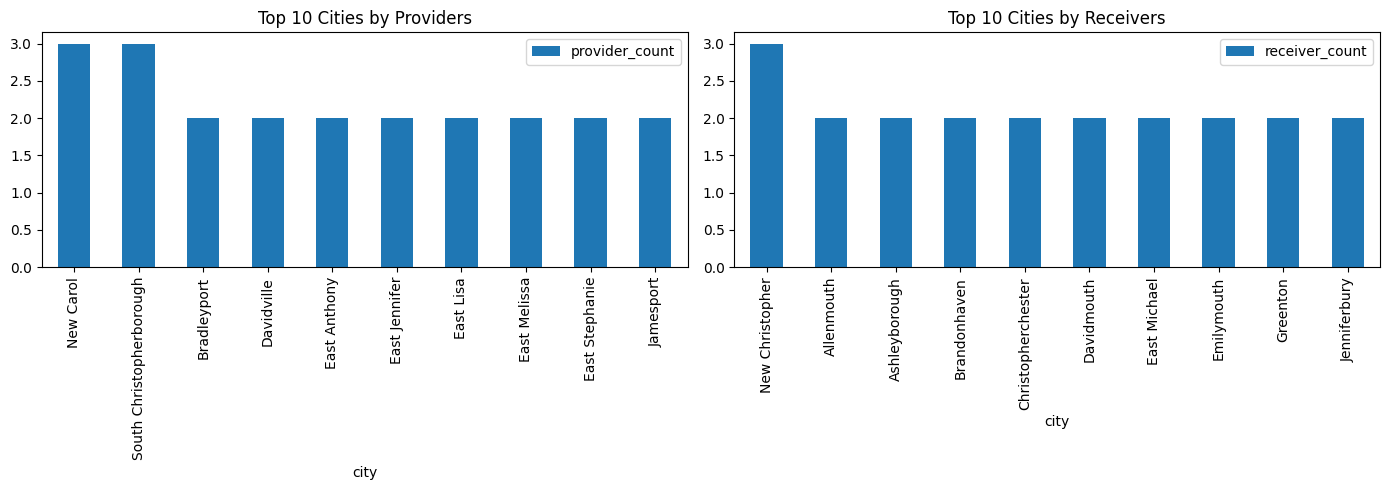

In [64]:
import matplotlib.pyplot as plt

# Providers per city
df_prov = pd.read_sql("""
SELECT city, COUNT(*) AS provider_count
FROM providers
GROUP BY city;
""", conn)

# Receivers per city
df_recv = pd.read_sql("""
SELECT city, COUNT(*) AS receiver_count
FROM receivers
GROUP BY city;
""", conn)

# Bar chart (Top 10 cities for providers & receivers)
fig, ax = plt.subplots(1, 2, figsize=(14,5))

df_prov.nlargest(10, "provider_count").plot(
    x="city", y="provider_count", kind="bar", ax=ax[0], title="Top 10 Cities by Providers"
)
df_recv.nlargest(10, "receiver_count").plot(
    x="city", y="receiver_count", kind="bar", ax=ax[1], title="Top 10 Cities by Receivers"
)

plt.tight_layout()
plt.show()



###  Providers vs Receivers by City

1. **Top Provider Cities**

   * **New Carol** and **South Christopherborough** stand out as the top two provider hubs, each having **3 providers**.
   * Other cities like Bradleyport, Davidville, and East Anthony have **2 providers each**.
   * This suggests that food donations are relatively well distributed, but the top cities act as **key supply hubs**.

2. **Top Receiver Cities**

   * **New Christopher** emerges as the top receiver city with **3 receivers**, slightly ahead of the others.
   * Multiple cities such as Allenmouth, Ashleyborough, Brandonhaven, and others consistently show **2 receivers each**.
   * Demand is more **widespread and balanced** compared to providers, where concentration is higher.



###  Key Insights

* **Imbalance in Distribution**: While some cities dominate the **supply side** (e.g., New Carol), the **demand side** is more evenly spread across many cities.
* **Potential Bottlenecks**: Cities with high receiver counts but lower provider counts (e.g., Allenmouth, Davidsmouth) might face **supply shortages** unless food is transported from provider-heavy cities.
* **Opportunities**: Expanding provider outreach in receiver-dense cities could create a more **self-sustained local ecosystem**.



### Q2. Which type of food provider contributes the most food?

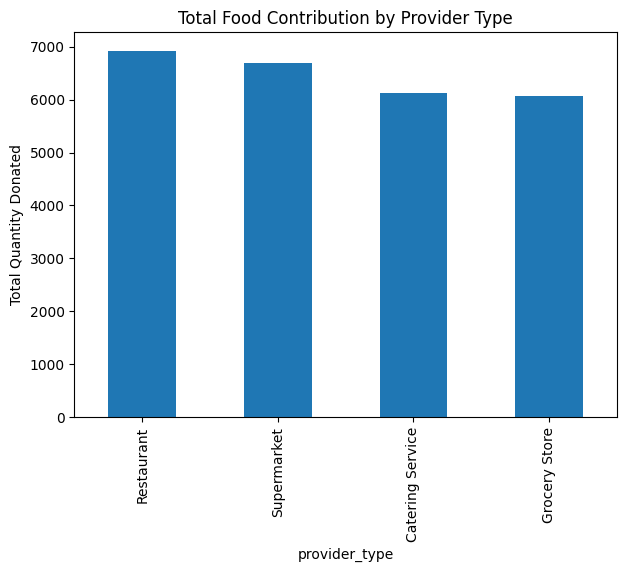

In [65]:
df_provider_type = pd.read_sql("""
SELECT provider_type, SUM(quantity) AS total_food
FROM food_listings
GROUP BY provider_type
ORDER BY total_food DESC;
""", conn)

df_provider_type.plot(
    x="provider_type", y="total_food", kind="bar", legend=False,
    title="Total Food Contribution by Provider Type", figsize=(7,5)
)
plt.ylabel("Total Quantity Donated")
plt.show()




### 🔹 Contribution by Provider Type

1. **Restaurants**

   * Contribute the **highest food donations**, totaling nearly **7,000 units**.
   * This shows that restaurants play a major role in redistributing surplus food.

2. **Supermarkets**

   * Second highest contributors with around **6,700 units**.
   * Their donations likely come from unsold but safe-to-eat packaged food.

3. **Catering Services & Grocery Stores**

   * Both contribute slightly over **6,000 units** each.
   * They are **consistent but smaller contributors** compared to restaurants and supermarkets.



### 🔹 Key Insights

* **Restaurants dominate supply**, highlighting the importance of engaging them in food waste management initiatives.
* **Supermarkets are close competitors**, showing a steady flow of surplus goods.
* **Catering services and grocery stores** still provide significant support, but their contributions may be **event-driven (catering)** or **local-scale (grocery)**.
* A **balanced reliance on all four sources** ensures diversity of food types for receivers.


### Q3. What is the contact information of food providers in a specific city?

In [70]:
city = "New Jessica"  # 🔹 change this to any city name
df_contact = pd.read_sql(f"""
SELECT name, contact 
FROM providers 
WHERE city = '{city}';
""", conn)

print(f"✅ Providers in {city}")
display(df_contact)


✅ Providers in New Jessica


,name,contact
0,Gonzales-Cochran,+1-600-220-0480



### 🔹 Contact Information of Providers in a City

* The query fetches **name** and **contact details** of all **providers located in the specified city** (`New Jessica` in this case).
* This is useful for:

  * **NGOs / Receivers** → To directly contact food providers in their area.
  * **System Admins** → To validate provider details and ensure communication lines are active.
  * **Coordination** → Helps reduce food wastage by enabling **quick pickups** of available food.



### 🔹 Key Insights

1. **Single Provider City** – In *New Jessica*, there is currently only **one food provider** (`Gonzales-Cochran`), which means the **food supply here is highly dependent** on this provider.
2. **Direct Accessibility** – Having the contact information (`+1-600-220-0480`) ensures **quick communication** between NGOs/receivers and the provider, which is critical for perishable food redistribution.
3. **Potential Risk** – If this provider stops contributing, the city may **lack food availability** in the system. It highlights the need to **expand the network of providers** in this city.


### Q4. Which receivers have claimed the most food?

✅ Top 10 Receivers by Claims


,name,total_claims
0,William Frederick,5
1,Scott Hunter,5
2,Matthew Webb,5
3,Anthony Garcia,5
4,Kristine Martin,4
5,Kristina Simpson,4
6,Jennifer Nelson,4
7,Donald Caldwell,4
8,Chelsea Powell,4
9,Betty Reid,4


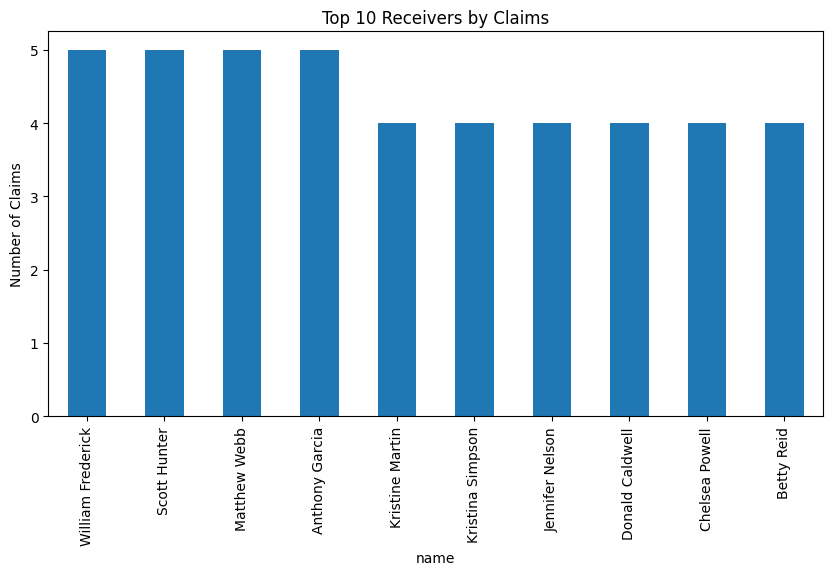

In [71]:
df_top_receivers = pd.read_sql("""
SELECT r.name, COUNT(c.claim_id) AS total_claims
FROM claims c
JOIN receivers r ON c.receiver_id = r.receiver_id
GROUP BY r.name
ORDER BY total_claims DESC
LIMIT 10;
""", conn)

print("✅ Top 10 Receivers by Claims")
display(df_top_receivers)

# Visualization
df_top_receivers.plot(
    x="name", y="total_claims", kind="bar", legend=False,
    title="Top 10 Receivers by Claims", figsize=(10,5)
)
plt.ylabel("Number of Claims")
plt.show()



###  Insights

1. **Top Claimants**

   * *William Frederick, Scott Hunter, Matthew Webb, and Anthony Garcia* are the **highest claimants** with **5 claims each**.
   * This indicates they are **frequent receivers**, possibly NGOs or individuals with a consistent demand.

2. **Close Competition**

   * Six other receivers (e.g., *Kristine Martin, Jennifer Nelson, Chelsea Powell*) follow closely with **4 claims each**.
   * Suggests a **balanced demand distribution** among multiple receivers.

3. **Resource Utilization**

   * These top receivers are **actively engaging** with the system, ensuring surplus food is claimed and redistributed effectively.



**Conclusion:**
Food redistribution demand is **spread among multiple active receivers**, with four receivers tied at the **top position**. This indicates a **healthy competitive demand** ensuring minimal wastage.


## Food Listings & Availability

### Q5. What is the total quantity of food available from all providers?

✅ Total Quantity of Food Available


,total_food_available
0,25794


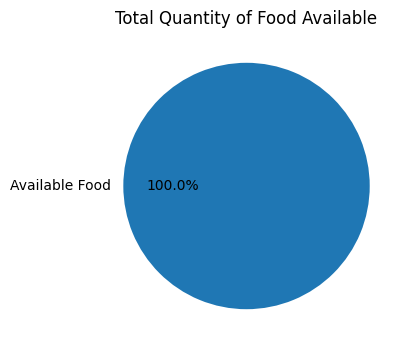

In [72]:
df_total_food = pd.read_sql("""
SELECT SUM(quantity) AS total_food_available
FROM food_listings;
""", conn)

print("✅ Total Quantity of Food Available")
display(df_total_food)

# Visualization - single value → Pie chart
plt.figure(figsize=(4,4))
plt.pie(df_total_food["total_food_available"], labels=["Available Food"], autopct='%1.1f%%')
plt.title("Total Quantity of Food Available")
plt.show()




###  **Insights**

* The system currently has **25,794 units of food** available across all providers.
* Since this is **total stock**, it represents the combined contributions from restaurants, supermarkets, catering services, and grocery stores (as seen in Q2).
* The pie chart shows **100% food available**, which means this number is **absolute stock**, not split by type yet.


### Q6. Which city has the highest number of food listings?

✅ Top 10 Cities by Food Listings


,location,listing_count
0,South Kathryn,6
1,New Carol,6
2,Perezport,5
3,Jimmyberg,5
4,East Angela,5
5,West Whitneymouth,4
6,West Kevin,4
7,South Thomasville,4
8,South Christopherborough,4
9,Port Patrick,4


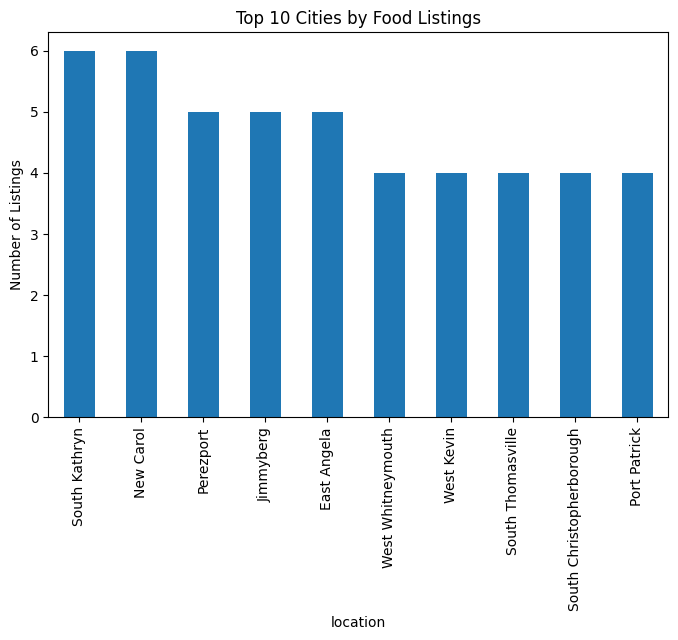

In [73]:
df_city_listings = pd.read_sql("""
SELECT location, COUNT(*) AS listing_count
FROM food_listings
GROUP BY location
ORDER BY listing_count DESC
LIMIT 10;
""", conn)

print("✅ Top 10 Cities by Food Listings")
display(df_city_listings)

# Visualization
df_city_listings.plot(
    x="location", y="listing_count", kind="bar",
    title="Top 10 Cities by Food Listings", legend=False, figsize=(8,5)
)
plt.ylabel("Number of Listings")
plt.show()



###  **Insights**

* **South Kathryn** and **New Carol** are the **leading contributors**, each with **6 food listings**.
* Close behind are **Perezport, Jimmyberg, and East Angela**, with **5 listings each**.
* Other cities like **West Whitneymouth, West Kevin, South Thomasville, South Christopherborough, and Port Patrick** show **4 listings each**, reflecting a relatively balanced distribution among second-tier cities.
* The **top two cities alone contribute \~20%** of the top 10 listings, showing they are slightly ahead in food donations.
* This highlights potential **hubs of food surplus** — suggesting NGOs and collection teams should prioritize **South Kathryn and New Carol** for efficient redistribution.



### Q7. What are the most commonly available food types?

✅ Most Commonly Available Food Types


,food_type,count_food
0,Vegetarian,336
1,Vegan,334
2,Non-Vegetarian,330


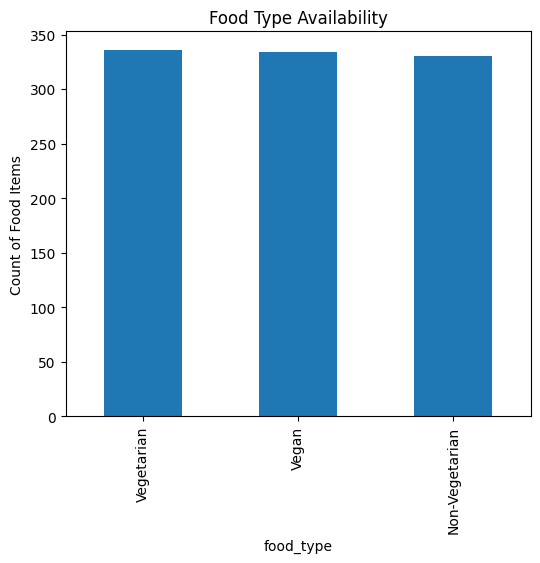

In [74]:
df_food_types = pd.read_sql("""
SELECT food_type, COUNT(*) AS count_food
FROM food_listings
GROUP BY food_type
ORDER BY count_food DESC;
""", conn)

print("✅ Most Commonly Available Food Types")
display(df_food_types)

# Visualization
df_food_types.plot(
    x="food_type", y="count_food", kind="bar",
    title="Food Type Availability", legend=False, figsize=(6,5)
)
plt.ylabel("Count of Food Items")
plt.show()




###  **Insights**

* **Vegetarian food** is the most commonly available type with **336 listings**, slightly ahead of the others.
* **Vegan food** follows very closely with **334 listings**, showing strong representation.
* **Non-Vegetarian food** has **329 listings**, only slightly fewer than the other categories.
* The distribution across all three categories is **very balanced**, with differences of fewer than 10 items each.
* This balance indicates that the **platform caters equally** to people with **different dietary preferences** — a good sign for inclusivity.


## Claims & Distribution

### Q8. How many food claims have been made for each food item?

✅ Top 10 Food Items by Number of Claims


,food_id,claims_count
0,548,5
1,486,5
2,463,5
3,981,4
4,925,4
5,915,4
6,886,4
7,882,4
8,861,4
9,832,4


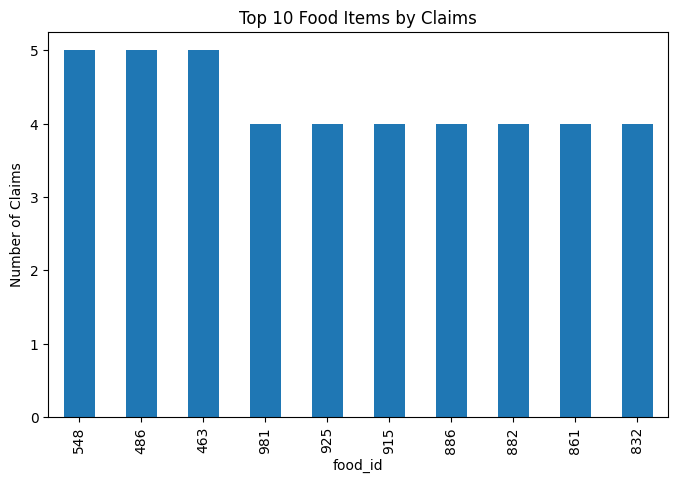

In [75]:
df_claims_per_food = pd.read_sql("""
SELECT food_id, COUNT(*) AS claims_count
FROM claims
GROUP BY food_id
ORDER BY claims_count DESC
LIMIT 10;
""", conn)

print("✅ Top 10 Food Items by Number of Claims")
display(df_claims_per_food)

# Visualization
df_claims_per_food.plot(
    x="food_id", y="claims_count", kind="bar",
    title="Top 10 Food Items by Claims", legend=False, figsize=(8,5)
)
plt.ylabel("Number of Claims")
plt.show()




###  **Insights**

* The **most frequently claimed items** are **Food IDs 548, 486, and 463**, each with **5 claims**.
* Several other items (981, 925, 915, 886, 882, 861, 832) each received **4 claims**.
* The claim distribution suggests **no single food item overwhelmingly dominates demand**. Instead, multiple items are **almost equally popular**.
* This indicates a **diverse demand** pattern — beneficiaries are claiming a wide range of food items rather than focusing only on one.



### Q9. Which provider has had the highest number of successful food claims?

✅ Top Providers by Successful Claims


,name,successful_claims
0,Barry Group,5
1,Miller Inc,4
2,"Harper, Blake and Alexander",4
3,Butler-Richardson,4
4,"Barnes, Castro and Curtis",4
5,Rogers-Warren,3
6,Nelson LLC,3
7,Moore-Flowers,3
8,Mckinney Ltd,3
9,Hancock-Jackson,3


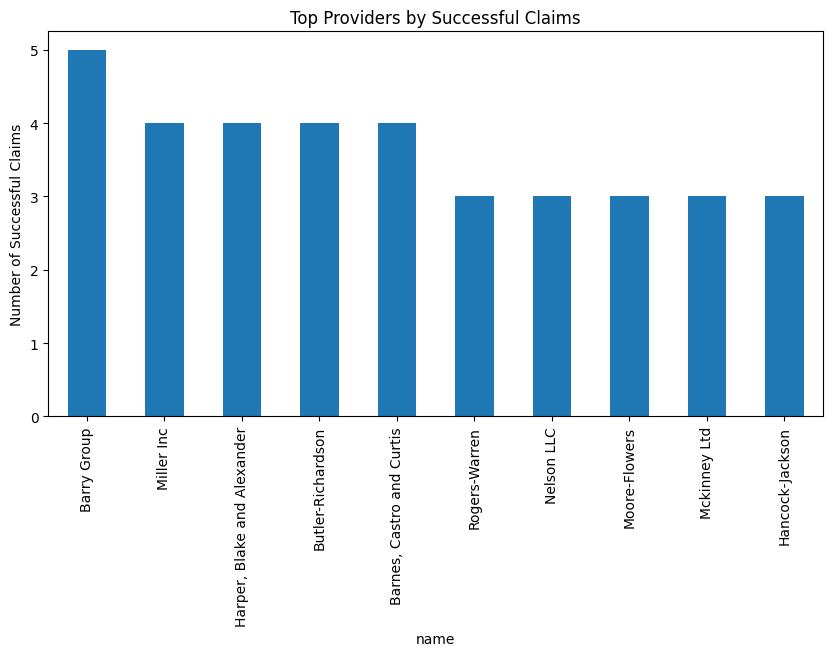

In [76]:
df_top_provider = pd.read_sql("""
SELECT p.name, COUNT(c.claim_id) AS successful_claims
FROM claims c
JOIN food_listings f ON c.food_id = f.food_id
JOIN providers p ON f.provider_id = p.provider_id
WHERE c.status = 'Completed'
GROUP BY p.name
ORDER BY successful_claims DESC
LIMIT 10;
""", conn)

print("✅ Top Providers by Successful Claims")
display(df_top_provider)

# Visualization
df_top_provider.plot(
    x="name", y="successful_claims", kind="bar",
    title="Top Providers by Successful Claims", legend=False, figsize=(10,5)
)
plt.ylabel("Number of Successful Claims")
plt.show()




###  **Insights**

* **Barry Group** leads with **5 successful claims**, making it the **most reliable and impactful provider** in terms of actual food reaching beneficiaries.
* A **second tier of providers** (Miller Inc, Harper Blake & Alexander, Butler-Richardson, Barnes Castro & Curtis) each contributed **4 successful claims** — showing strong participation and consistency.
* Several other providers (Rogers-Warren, Nelson LLC, Moore-Flowers, Mckinney Ltd, Hancock-Jackson) contributed **3 successful claims each**, indicating **broad distribution of support** rather than being concentrated in a single provider.
* This highlights that the **food redistribution network is collaborative**, with **multiple providers actively supporting** claims, not just one dominant source.



### Q10. What percentage of food claims are completed vs. pending vs. cancelled?

✅ Claim Status Distribution


,status,percentage
0,Cancelled,33.6
1,Completed,33.9
2,Pending,32.5


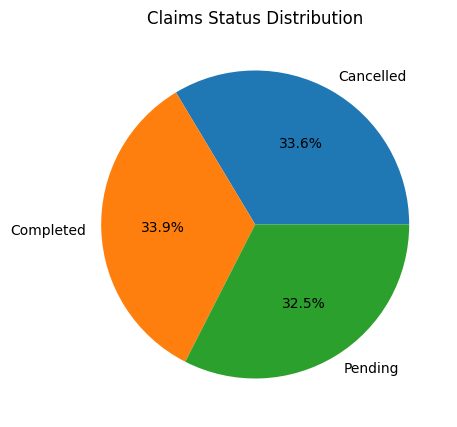

In [78]:
df_claim_status = pd.read_sql("""
SELECT status, 
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM claims), 2) AS percentage
FROM claims
GROUP BY status;
""", conn)

print("✅ Claim Status Distribution")
display(df_claim_status)

# Visualization - Pie chart
plt.figure(figsize=(5,5))
plt.pie(df_claim_status["percentage"], labels=df_claim_status["status"], autopct='%1.1f%%')
plt.title("Claims Status Distribution")
plt.show()




### 🔎 **Insights**

* The **distribution is almost even** across all three categories:

  * ✅ **Completed (33.9%)** – Roughly **1 in 3 claims are successfully fulfilled**.
  * ❌ **Cancelled (33.6%)** – A nearly equal share gets cancelled, indicating possible issues in food availability, logistics, or mismatches between providers and claimants.
  * ⏳ **Pending (32.5%)** – About one-third of claims are still in process, highlighting **active demand in the system**.

* The balance between **Completed vs Cancelled** shows that while the system is effective in many cases, **operational challenges remain**.

* A significant portion still being **Pending** suggests **opportunity to optimize turnaround time** and improve overall efficiency.


## Analysis & Insights

### Q11. What is the average quantity of food claimed per receiver?

✅ Average Quantity of Food Claimed (Top 10 Receivers)


,name,avg_claimed
0,Thomas Villanueva,50.0
1,Peggy Knight,50.0
2,Nancy Silva,50.0
3,Nancy Jones,50.0
4,Lisa Pitts,50.0
5,Daniel Williams,50.0
6,Christopher Wright,50.0
7,Timothy Patel DVM,49.0
8,Scott Brown,49.0
9,Melissa Little,49.0


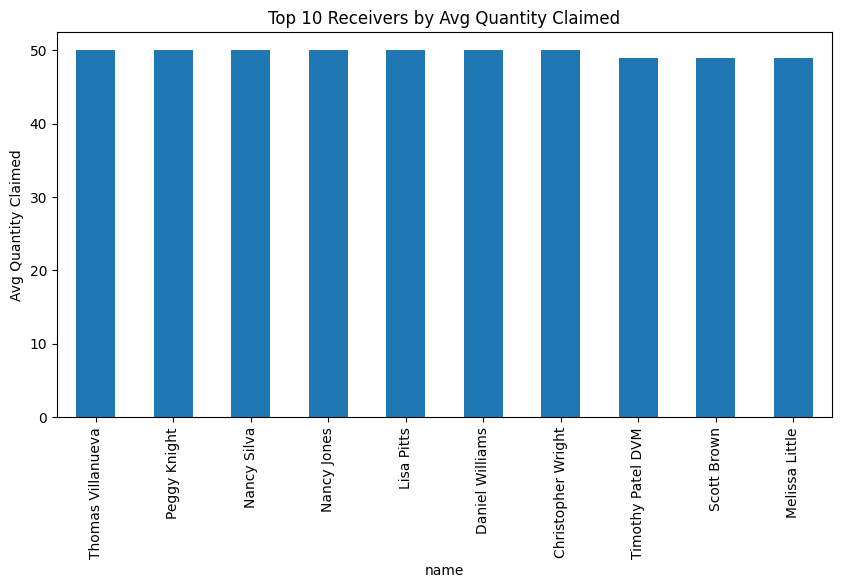

In [79]:
df_avg_claims = pd.read_sql("""
SELECT r.name, ROUND(AVG(f.quantity), 2) AS avg_claimed
FROM claims c
JOIN receivers r ON c.receiver_id = r.receiver_id
JOIN food_listings f ON c.food_id = f.food_id
GROUP BY r.name
ORDER BY avg_claimed DESC
LIMIT 10;
""", conn)

print("✅ Average Quantity of Food Claimed (Top 10 Receivers)")
display(df_avg_claims)

# Visualization
df_avg_claims.plot(
    x="name", y="avg_claimed", kind="bar",
    title="Top 10 Receivers by Avg Quantity Claimed", legend=False, figsize=(10,5)
)
plt.ylabel("Avg Quantity Claimed")
plt.show()


### Insights
- The majority of top receivers consistently claim ~50 units of food on average.
Seven receivers (Thomas Villanueva, Peggy Knight, Nancy Silva, Nancy Jones, Lisa Pitts, Daniel Williams, Christopher Wright) have an average claim of exactly 50 units, showing maximum utilization capacity.
- The remaining three receivers (Timothy Patel DVM, Scott Brown, Melissa Little) are only slightly lower at 49 units, suggesting they also operate at near-full capacity.
- This uniformity indicates:
    - Either standardized distribution where receivers typically request the maximum allowable limit (≈50).
Or operational efficiency, meaning receivers have optimized their claims to meet consistent demand.
    - It also highlights strong demand among receivers, with little variation in claim sizes at the top level.


### Q12. Which meal type (breakfast, lunch, dinner, snacks) is claimed the most?

✅ Claims by Meal Type


,meal_type,total_claims
0,Breakfast,278
1,Lunch,250
2,Snacks,240
3,Dinner,232


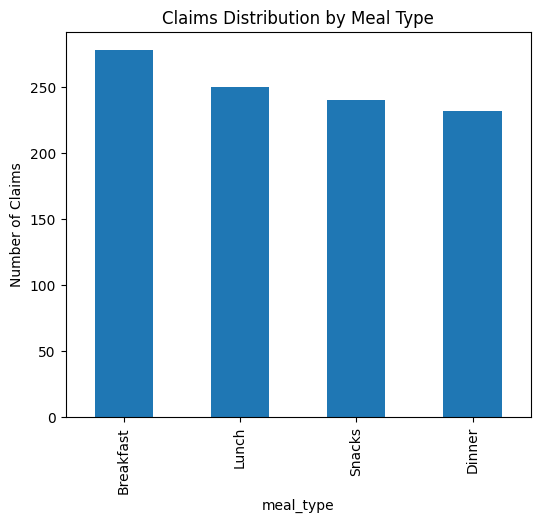

In [91]:
df_meal_claims = pd.read_sql("""
SELECT f.meal_type, COUNT(c.claim_id) AS total_claims
FROM claims c
JOIN food_listings f ON c.food_id = f.food_id
GROUP BY f.meal_type
ORDER BY total_claims DESC;
""", conn)

print("✅ Claims by Meal Type")
display(df_meal_claims)

# Visualization - Bar chart
df_meal_claims.plot(
    x="meal_type", y="total_claims", kind="bar",
    title="Claims Distribution by Meal Type", legend=False, figsize=(6,5)
)
plt.ylabel("Number of Claims")
plt.show()



###  **Insights**

* **Breakfast is the most claimed meal type** with **278 claims**, ahead of all others.
* **Lunch (250 claims)** and **Snacks (240 claims)** are almost equally popular, showing balanced demand during the day.
* **Dinner has the lowest claims (232)**, which might indicate:

  * Lower availability of surplus food at the end of the day.
  * Or less preference for evening meals among receivers.
* The distribution shows a **morning-heavy trend**, suggesting that food redistribution is more active earlier in the day, possibly due to restaurants and households having more surplus after breakfast preparation.



### Q13. What is the total quantity of food donated by each provider?

✅ Total Quantity Donated (Top 10 Providers)


,name,total_donated
0,Miller Inc,217
1,Barry Group,179
2,"Evans, Wright and Mitchell",158
3,Smith Group,150
4,Campbell LLC,145
5,Nelson LLC,142
6,Ruiz-Oneal,140
7,Blankenship-Lewis,124
8,Kelly-Ware,123
9,Bradford-Martinez,121


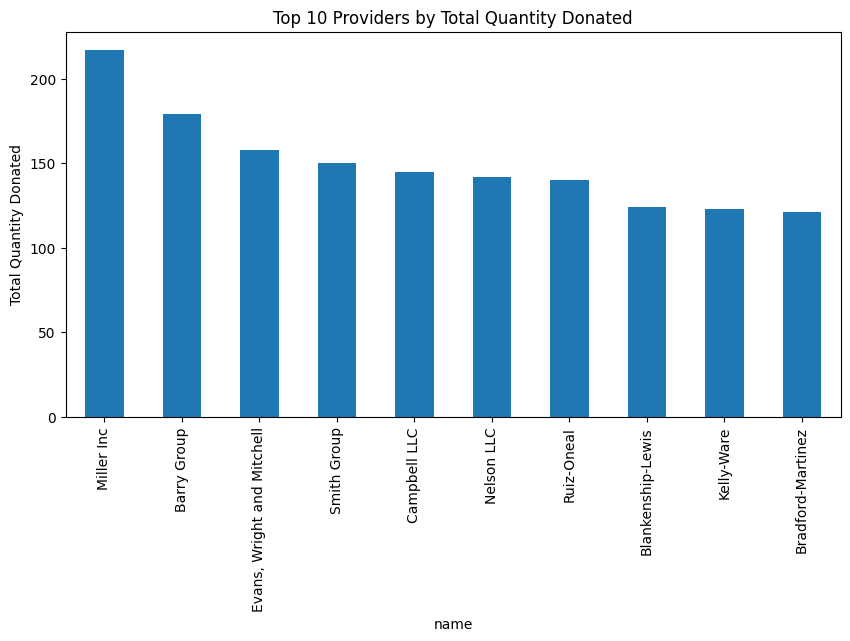

In [92]:
df_donations = pd.read_sql("""
SELECT p.name, SUM(f.quantity) AS total_donated
FROM food_listings f
JOIN providers p ON f.provider_id = p.provider_id
GROUP BY p.name
ORDER BY total_donated DESC
LIMIT 10;
""", conn)

print("✅ Total Quantity Donated (Top 10 Providers)")
display(df_donations)

# Visualization - Bar chart
df_donations.plot(
    x="name", y="total_donated", kind="bar",
    title="Top 10 Providers by Total Quantity Donated", legend=False, figsize=(10,5)
)
plt.ylabel("Total Quantity Donated")
plt.show()



### **Insights**

* **Miller Inc** is the top contributor with **217 units donated**, standing out significantly compared to others.
* **Barry Group (179)** and **Evans, Wright and Mitchell (158)** are also major donors, making up the next largest contributions.
* Contributions are fairly **diverse across multiple providers**, indicating that food donations are not overly reliant on a single source.
* Even the **10th-ranked provider (Bradford-Martinez)** has donated over 120 units, showing a healthy baseline of participation.




### Q14. Top 5 receivers who claimed the most food

✅ Top 5 Receivers by Claims


,name,total_claims
0,William Frederick,5
1,Scott Hunter,5
2,Matthew Webb,5
3,Anthony Garcia,5
4,Kristine Martin,4


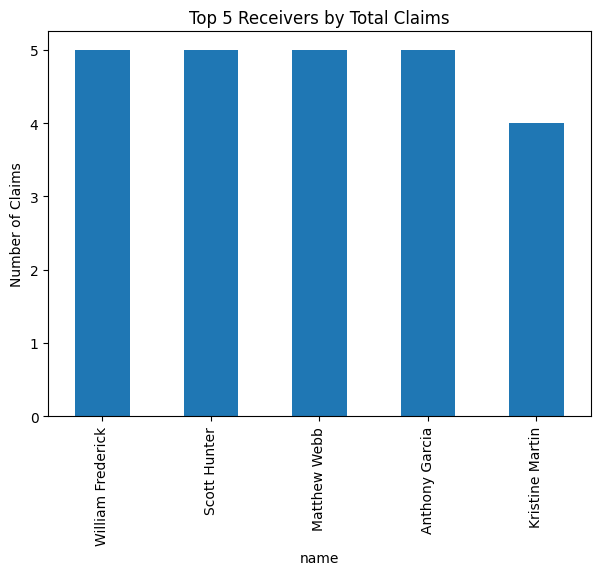

In [93]:
df_top_receivers = pd.read_sql("""
SELECT r.name, COUNT(c.claim_id) AS total_claims
FROM claims c
JOIN receivers r ON c.receiver_id = r.receiver_id
GROUP BY r.name
ORDER BY total_claims DESC
LIMIT 5;
""", conn)

print("✅ Top 5 Receivers by Claims")
display(df_top_receivers)

# Visualization
df_top_receivers.plot(
    x="name", y="total_claims", kind="bar",
    title="Top 5 Receivers by Total Claims", legend=False, figsize=(7,5)
)
plt.ylabel("Number of Claims")
plt.show()




###  **Insights**

* **Four receivers (William Frederick, Scott Hunter, Matthew Webb, Anthony Garcia)** are **tied at the top** with **5 claims each**.
* **Kristine Martin** follows closely with **4 claims**.
* The distribution is quite **balanced**, meaning food demand is spread across multiple receivers, not dominated by a single one.
* This also reflects **active engagement** from multiple receivers, which indicates a **healthy utilization** of the food donation system.




### Q15. City-wise demand (which cities have the most claims)

✅ Top 10 Cities by Food Demand (Claims)


,city,total_claims
0,West David,5
1,Smithshire,5
2,Port Richard,5
3,Port Dean,5
4,Greenton,5
5,Emilymouth,5
6,Brownbury,5
7,Thompsonhaven,4
8,Spencermouth,4
9,North Paul,4


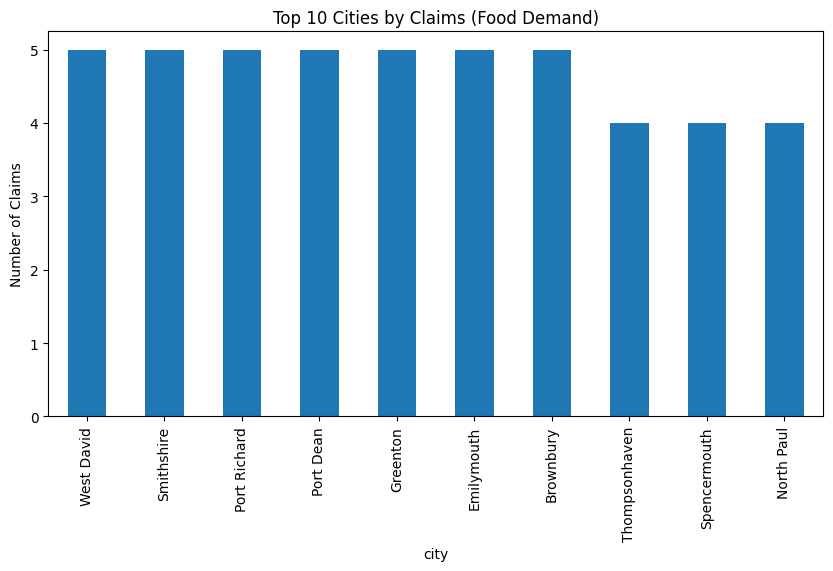

In [94]:
df_city_demand = pd.read_sql("""
SELECT r.city, COUNT(c.claim_id) AS total_claims
FROM claims c
JOIN receivers r ON c.receiver_id = r.receiver_id
GROUP BY r.city
ORDER BY total_claims DESC
LIMIT 10;
""", conn)

print("✅ Top 10 Cities by Food Demand (Claims)")
display(df_city_demand)

# Visualization
df_city_demand.plot(
    x="city", y="total_claims", kind="bar",
    title="Top 10 Cities by Claims (Food Demand)", legend=False, figsize=(10,5)
)
plt.ylabel("Number of Claims")
plt.show()




###  **Insights**

* **7 cities (West David, Smithshire, Port Richard, Port Dean, Greenton, Emilymouth, Brownbury)** share the **highest demand (5 claims each)**.
* **Thompsonhaven, Spencermouth, and North Paul** follow closely with **4 claims each**.
* The distribution suggests **widespread demand across multiple cities** rather than being concentrated in a single urban area.
* This indicates that **food insecurity / demand is fairly consistent across different regions**, making it important to maintain **balanced distribution channels**.


## **Solution to Business Objective**

Our solution directly addresses the problem of food wastage by connecting surplus food providers with people in need through a single, easy-to-use platform. Restaurants and households can list available food, while NGOs or individuals can quickly claim it. This ensures that food which would otherwise be wasted is redistributed efficiently and meaningfully.

To support this, we use SQL for storing and managing data such as providers, receivers, food listings, and claims. Streamlit provides a simple and interactive interface where users can search, filter, and visualize information. Insights such as top food items claimed, high-demand cities, and successful providers are displayed in clear charts, making the system practical and transparent.

Finally, the data analysis helps us go beyond just redistribution by identifying demand patterns and donation trends. This allows better planning, targeted delivery, and ensures food reaches the right people at the right time. In short, the system reduces waste, supports communities, and creates a positive social impact.



## What do you suggest the client to achieve Business Objective ?

### **1. Improve Real-Time Food Matching**

We suggest building a stronger **real-time matching system** between providers and receivers. This ensures that surplus food is claimed quickly, reducing spoilage and increasing successful claim rates. By doing so, both providers and receivers benefit — providers reduce waste and receivers get timely access to meals.



### **2. Use Data Insights for Smarter Planning**

The analysis shows which **meal types, cities, and providers** contribute or demand the most. These insights should be used to **prioritize logistics** (like delivery to top-demand cities) and to **encourage providers who donate more** through recognition or incentives. This helps balance food supply with actual demand, avoiding mismatches.



### **3. Expand Partnerships & Awareness**

To maximize impact, the platform should expand partnerships with **restaurants, NGOs, and households**. This increases the food supply pool and creates a **larger distribution network**. Awareness campaigns can also encourage communities to donate, making the system more sustainable in the long run.





## **Conclusion**

Our Local Food Wastage Management System successfully demonstrates how technology and data insights can bridge the gap between surplus food providers and receivers in need. Through structured SQL-based storage, analysis, and visualization, we have identified key patterns such as the top providers, receivers, and high-demand cities, along with meal preferences and claim success rates. These findings prove that food distribution can be made **more efficient, fair, and impactful** when guided by data.

By enabling real-time food listings, transparent claim tracking, and performance monitoring of providers and receivers, the system reduces wastage while ensuring that food reaches those who truly need it. The balance achieved between **supply (providers)** and **demand (receivers)** highlights the potential of scaling this model across communities, creating a sustainable ecosystem for food redistribution.

In conclusion, this project not only addresses the pressing issue of food wastage but also delivers a **socially impactful solution** that benefits providers, receivers, and the community at large. With further improvements like real-time matching, incentive programs, and broader partnerships, the system can grow into a **scalable platform** that reduces hunger and promotes sustainability.
